# Molecular Dynamics Trajectory Analysis
## Comprehensive Analysis Tool for MD Simulations

**Features:**
- RMSD (Root Mean Square Deviation)
- RMSF (Root Mean Square Fluctuation)
- Radius of Gyration (Rg)
- Free Energy Landscape (FEL)
- MM Binding Energy (Electrostatic + VdW)
- Protein-Ligand Distance Analysis

---
**Author:** SciLearningWorkshops LLC  
**Compatible with:** GROMACS, AMBER, CHARMM, NAMD trajectories

In [ ]:
#@title ##**Install Required Packages**
!pip install MDAnalysis matplotlib seaborn numpy scipy -q
print("✓ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.2 MB/s eta 0:00:00
✓ All packages installed successfully!


In [ ]:
#@title ##**Mounts drive and changes the directory to the folder previously created**

from google.colab import drive
import os
from IPython.display import display
import ipywidgets as widgets

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

instruction_label = widgets.HTML(
    value="<b>Tip:</b> To search for folders within folders, use <code>/</code> to separate them. For example: <code>Folder1/Subfolder1</code>"
)

folder_input = widgets.Text(
    value='',
    placeholder='Enter part of the folder name (e.g., Folder/Subfolder)',
    description='Search:',
    layout=widgets.Layout(width='50%')
)

button_style = {
    'font_weight': 'bold',
    'button_color': '#4CAF50',
    'font_size': '16px'
}
button_layout = widgets.Layout(width='auto', height='40px')

search_button = widgets.Button(
    description='Search',
    style=button_style,
    layout=button_layout
)

search_message_output = widgets.Output()

folder_dropdown = widgets.Dropdown(
    options=[],
    description='Select:',
    layout=widgets.Layout(width='50%')
)

confirm_button = widgets.Button(
    description='Set Directory',
    style=button_style,
    layout=button_layout
)

output = widgets.Output()

def search_folders(b):
    base_path = '/content/drive/MyDrive'
    matches = []
    search_term = folder_input.value.lower()

    with search_message_output:
        search_message_output.clear_output()
        print("Searching for folders... Please be patient, this may take up to 30 seconds.")

    if search_term:
        for root, dirs, files in os.walk(base_path):
            for d in dirs:
                full_path = os.path.join(root, d)
                relative_path = os.path.relpath(full_path, base_path)
                if search_term in relative_path.lower():
                    matches.append(full_path)
        folder_dropdown.options = matches if matches else ['No matches found']

def set_directory(b):
    selected_path = folder_dropdown.value
    if selected_path and selected_path != 'No matches found':
        os.chdir(selected_path)
        with output:
            output.clear_output()
            print(f"✓ Current directory: {os.getcwd()}")

search_button.on_click(search_folders)
confirm_button.on_click(set_directory)

display(
    instruction_label,
    folder_input,
    search_button,
    search_message_output,
    folder_dropdown,
    confirm_button,
    output
)

Mounted at /content/drive


HTML(value='<b>Tip:</b> To search for folders within folders, use <code>/</code> to separate them. For example…

Text(value='', description='Search:', layout=Layout(width='50%'), placeholder='Enter part of the folder name (…

Button(description='Search', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color='#4CAF…

Output()

Dropdown(description='Select:', layout=Layout(width='50%'), options=(), value=None)

Button(description='Set Directory', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color…

Output()

In [ ]:
#@title ##**MD Trajectory Analysis Tool - Core Functions**

import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
from MDAnalysis.analysis.rms import RMSF
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10

class MDAnalyzer:
    def __init__(self, topology, trajectory, protein_selection="protein", ligand_selection="resname LIG"):
        """
        Initialize MD Analyzer

        Parameters:
        -----------
        topology : str
            Path to PDB or GRO file
        trajectory : str
            Path to trajectory file (XTC, TRR, DCD, etc.)
        protein_selection : str
            MDAnalysis selection string for protein
        ligand_selection : str
            MDAnalysis selection string for ligand
        """
        print("Loading trajectory... This may take a moment.")
        self.u = mda.Universe(topology, trajectory)
        self.protein = self.u.select_atoms(protein_selection)
        self.ligand = self.u.select_atoms(ligand_selection)
        self.complex = self.u.select_atoms(f"{protein_selection} or {ligand_selection}")
        self.n_frames = len(self.u.trajectory)
        self.dt = self.u.trajectory.dt  # timestep in ps
        print(f"✓ Loaded {self.n_frames} frames")
        print(f"✓ Timestep: {self.dt} ps")
        print(f"✓ Protein atoms: {len(self.protein)}")
        print(f"✓ Ligand atoms: {len(self.ligand)}")

    def calculate_rmsd(self, selection="backbone", reference_frame=0):
        """Calculate RMSD over trajectory"""
        print("Calculating RMSD...")

        if selection == "backbone":
            sel = self.protein.select_atoms("backbone")
        elif selection == "ca":
            sel = self.protein.select_atoms("name CA")
        else:
            sel = self.protein.select_atoms(selection)

        R = rms.RMSD(sel, sel, select=selection, ref_frame=reference_frame)
        R.run()

        # Convert time to ns
        time_ns = R.results.rmsd[:, 1] / 1000.0
        rmsd_values = R.results.rmsd[:, 2]

        return time_ns, rmsd_values

    def plot_rmsd(self, save_path="rmsd.png"):
        """Plot RMSD vs Time"""
        time_ns, rmsd_values = self.calculate_rmsd()

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(time_ns, rmsd_values, linewidth=1.5, color='#2E86AB')
        ax.set_xlabel('Time (ns)', fontsize=12, fontweight='bold')
        ax.set_ylabel('RMSD (Å)', fontsize=12, fontweight='bold')
        ax.set_title('Backbone RMSD over Time', fontsize=14, fontweight='bold')
        ax.grid(alpha=0.3)

        # Add statistics - only mean line
        mean_rmsd = np.mean(rmsd_values)
        std_rmsd = np.std(rmsd_values)
        ax.axhline(mean_rmsd, color='red', linestyle='--', alpha=0.7,
                  label=f'Mean: {mean_rmsd:.2f} Å')
        ax.legend()

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ RMSD plot saved to {save_path}")
        plt.show()

        return time_ns, rmsd_values

    def calculate_rmsf(self, selection="ca"):
        """Calculate RMSF per residue"""
        print("Calculating RMSF...")

        # Use C-alpha atoms for RMSF calculation
        ca_atoms = self.protein.select_atoms("name CA")

        # Align trajectory using backbone
        backbone = self.protein.select_atoms("backbone")

        # Align all frames to first frame
        align.AlignTraj(self.u, self.u, select="backbone", in_memory=True).run()

        # Calculate RMSF
        rmsf_obj = RMSF(ca_atoms).run()
        rmsf_values = rmsf_obj.results.rmsf

        # Get residue numbers
        residue_numbers = ca_atoms.resnums

        return residue_numbers, rmsf_values

    def plot_rmsf(self, save_path="rmsf.png"):
        """Plot RMSF vs Residue"""
        residues, rmsf_values = self.calculate_rmsf()

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(residues, rmsf_values, linewidth=1.5, color='#A23B72')
        ax.set_xlabel('Residue Number', fontsize=12, fontweight='bold')
        ax.set_ylabel('RMSF (Å)', fontsize=12, fontweight='bold')
        ax.set_title('Root Mean Square Fluctuation per Residue', fontsize=14, fontweight='bold')
        ax.grid(alpha=0.3)

        # Highlight high fluctuation regions
        threshold = np.mean(rmsf_values) + np.std(rmsf_values)
        high_fluct = rmsf_values > threshold
        ax.axhline(threshold, color='red', linestyle='--', alpha=0.5, label=f'Threshold: {threshold:.2f} Å')
        ax.scatter(residues[high_fluct], rmsf_values[high_fluct],
                  color='red', s=30, zorder=5, label='High Fluctuation')
        ax.legend()

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ RMSF plot saved to {save_path}")
        plt.show()

        return residues, rmsf_values

    def calculate_rg(self, selection="protein"):
        """Calculate radius of gyration"""
        print("Calculating Radius of Gyration...")

        if selection == "protein":
            sel = self.protein
        else:
            sel = self.u.select_atoms(selection)

        rg_values = []
        time_ns = []

        for ts in self.u.trajectory:
            rg_values.append(sel.radius_of_gyration())
            time_ns.append(ts.time / 1000.0)  # Convert to ns

        return np.array(time_ns), np.array(rg_values)

    def plot_rg(self, save_path="rg.png"):
        """Plot Radius of Gyration vs Time"""
        time_ns, rg_values = self.calculate_rg()

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(time_ns, rg_values, linewidth=1.5, color='#F18F01')
        ax.set_xlabel('Time (ns)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Radius of Gyration (Å)', fontsize=12, fontweight='bold')
        ax.set_title('Protein Compactness over Time', fontsize=14, fontweight='bold')
        ax.grid(alpha=0.3)

        # Add statistics - only mean line
        mean_rg = np.mean(rg_values)
        std_rg = np.std(rg_values)
        ax.axhline(mean_rg, color='red', linestyle='--', alpha=0.7,
                  label=f'Mean: {mean_rg:.2f} Å')
        ax.legend()

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Rg plot saved to {save_path}")
        plt.show()

        return time_ns, rg_values

    def calculate_free_energy_landscape(self, rmsd_values=None, rg_values=None, bins=50, temperature=300):
        """
        Calculate Free Energy Landscape using RMSD and Rg

        Parameters:
        -----------
        rmsd_values : array, optional
            RMSD values (if None, will calculate)
        rg_values : array, optional
            Rg values (if None, will calculate)
        bins : int
            Number of bins for 2D histogram
        temperature : float
            Temperature in Kelvin
        """
        print("Calculating Free Energy Landscape...")

        if rmsd_values is None:
            _, rmsd_values = self.calculate_rmsd()
        if rg_values is None:
            _, rg_values = self.calculate_rg()

        # Create 2D histogram
        hist, xedges, yedges = np.histogram2d(rmsd_values, rg_values, bins=bins)

        # Convert to probability
        hist = hist / np.sum(hist)

        # Avoid log(0)
        hist[hist == 0] = np.min(hist[hist > 0]) * 0.01

        # Calculate free energy: ΔG = -RT ln(P)
        kB = 0.001987  # kcal/(mol·K)
        RT = kB * temperature
        free_energy = -RT * np.log(hist)

        # Normalize to minimum
        free_energy = free_energy - np.min(free_energy)

        return free_energy, xedges, yedges

    def plot_free_energy_landscape(self, save_path="fel.png", temperature=300):
        """Plot Free Energy Landscape and identify global minimum frame"""
        _, rmsd_values = self.calculate_rmsd()
        _, rg_values = self.calculate_rg()

        fel, xedges, yedges = self.calculate_free_energy_landscape(
            rmsd_values, rg_values, temperature=temperature
        )

        # Smooth the FEL
        fel_smooth = gaussian_filter(fel, sigma=1.0)

        # Find global minimum in the FEL
        min_idx = np.unravel_index(np.argmin(fel_smooth), fel_smooth.shape)
        min_rmsd = xedges[min_idx[0]]
        min_rg = yedges[min_idx[1]]

        # Find the frame closest to the global minimum
        # Calculate distance from each point to the minimum
        distances_to_min = np.sqrt((rmsd_values - min_rmsd)**2 + (rg_values - min_rg)**2)
        min_frame_idx = np.argmin(distances_to_min)

        # Get time information
        min_time_ns = self.u.trajectory[min_frame_idx].time / 1000.0
        min_frame_number = min_frame_idx

        # Get RMSD and Rg at that frame
        actual_rmsd = rmsd_values[min_frame_idx]
        actual_rg = rg_values[min_frame_idx]

        fig, ax = plt.subplots(figsize=(6, 5))

        # Plot contour
        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        levels = np.linspace(0, np.percentile(fel_smooth, 95), 20)

        contour = ax.contourf(X, Y, fel_smooth.T, levels=levels, cmap='viridis')
        contour_lines = ax.contour(X, Y, fel_smooth.T, levels=levels, colors='white',
                                   linewidths=0.5, alpha=0.3)

        cbar = plt.colorbar(contour, ax=ax)
        cbar.set_label('Free Energy (kcal/mol)', fontsize=12, fontweight='bold')

        ax.set_xlabel('RMSD (Å)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Radius of Gyration (Å)', fontsize=12, fontweight='bold')
        ax.set_title('Free Energy Landscape', fontsize=14, fontweight='bold')

        # Mark global minimum on FEL
        ax.plot(xedges[min_idx[0]], yedges[min_idx[1]], 'r*', markersize=20,
               label='Global Minimum', markeredgecolor='white', markeredgewidth=1)

        # Mark the actual trajectory frame closest to global minimum
        ax.plot(actual_rmsd, actual_rg, 'yo', markersize=12,
               label=f'Frame {min_frame_number} ({min_time_ns:.2f} ns)',
               markeredgecolor='black', markeredgewidth=1.5)

        ax.legend()

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ FEL plot saved to {save_path}")

        # Print detailed information about global minimum
        print("\n" + "="*60)
        print("GLOBAL MINIMUM INFORMATION")
        print("="*60)
        print(f"FEL Global Minimum Position:")
        print(f"  RMSD: {min_rmsd:.3f} Å")
        print(f"  Rg:   {min_rg:.3f} Å")
        print(f"\nClosest Trajectory Frame:")
        print(f"  Frame Number: {min_frame_number}")
        print(f"  Time:         {min_time_ns:.3f} ns")
        print(f"  RMSD:         {actual_rmsd:.3f} Å")
        print(f"  Rg:           {actual_rg:.3f} Å")
        print(f"\nTo extract this frame from your trajectory:")
        print(f"  Frame index (0-based): {min_frame_idx}")
        print(f"  Time in trajectory:    {min_time_ns:.3f} ns")
        print("="*60 + "\n")

        plt.show()

        return fel, xedges, yedges, min_frame_idx, min_time_ns

    def calculate_binding_energy_mm(self):
        """
        Calculate MM binding energy (Electrostatic + VdW) in kJ/mol
        Uses simplified Coulomb and Lennard-Jones potentials
        """
        print("Calculating MM Binding Energy...")

        if len(self.ligand) == 0:
            print("Warning: No ligand found. Please check ligand selection.")
            return None, None

        energies = []
        time_ns = []

        # Constants
        epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
        epsilon_r = 1.0  # Relative permittivity (vacuum approximation)
        e = 1.602176634e-19  # Elementary charge (C)
        Na = 6.02214076e23  # Avogadro's number

        # Coulomb constant in kJ/(mol·nm)
        # k_e = (1 / (4π * ε₀ * ε_r)) * e² * Na / 1000
        k_e = 138.935458  # kJ·nm/(mol·e²) - standard value for MD simulations

        # Lennard-Jones parameters (typical protein-ligand values)
        epsilon_lj = 0.5  # kJ/mol - depth of potential well
        sigma = 0.35  # nm - distance at which potential is zero

        for ts in self.u.trajectory:
            # Get protein-ligand distance matrix in Angstroms
            distances_angstrom = mda.lib.distances.distance_array(
                self.protein.positions,
                self.ligand.positions
            )

            # Convert to nm for proper energy calculation
            distances_nm = distances_angstrom / 10.0

            # Avoid division by zero
            distances_nm = np.maximum(distances_nm, 0.01)  # Minimum distance 0.01 nm

            # Electrostatic energy (Coulomb's law)
            # E_elec = k_e * q1 * q2 / r
            # Assuming partial charges of ±0.5e for simplified calculation
            q_protein = 0.5  # Partial charge (elementary charge units)
            q_ligand = 0.5
            elec_energy = k_e * q_protein * q_ligand / distances_nm
            total_elec = np.sum(elec_energy)

            # Van der Waals energy (Lennard-Jones 6-12 potential)
            # E_vdw = 4ε[(σ/r)^12 - (σ/r)^6]
            sigma_r = sigma / distances_nm
            vdw_energy = 4 * epsilon_lj * (sigma_r**12 - sigma_r**6)
            total_vdw = np.sum(vdw_energy)

            # Total interaction energy
            total_energy = total_elec + total_vdw

            energies.append(total_energy)
            time_ns.append(ts.time / 1000.0)

        return np.array(time_ns), np.array(energies)

    def plot_binding_energy(self, save_path="binding_energy.png"):
        """Plot binding energy over time in kJ/mol"""
        time_ns, energies = self.calculate_binding_energy_mm()

        if energies is None:
            return None, None

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(time_ns, energies, linewidth=1.5, color='#6A4C93')
        ax.set_xlabel('Time (ns)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Interaction Energy (kJ/mol)', fontsize=12, fontweight='bold')
        ax.set_title('Protein-Ligand Interaction Energy', fontsize=14, fontweight='bold')
        ax.grid(alpha=0.3)

        mean_energy = np.mean(energies)
        std_energy = np.std(energies)
        ax.axhline(mean_energy, color='red', linestyle='--', alpha=0.7,
                  label=f'Mean: {mean_energy:.2f} kJ/mol')
        ax.legend()

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Binding energy plot saved to {save_path}")
        print(f"  Mean Energy: {mean_energy:.2f} ± {std_energy:.2f} kJ/mol")
        plt.show()

        return time_ns, energies

    def calculate_protein_ligand_distance(self, protein_sel="name CA", ligand_sel=None):
        """Calculate minimum distance between protein and ligand"""
        print("Calculating Protein-Ligand Distances...")

        if ligand_sel:
            ligand = self.u.select_atoms(ligand_sel)
        else:
            ligand = self.ligand

        if len(ligand) == 0:
            print("Warning: No ligand found.")
            return None, None

        protein_atoms = self.protein.select_atoms(protein_sel)

        distances = []
        time_ns = []

        for ts in self.u.trajectory:
            dist_array = mda.lib.distances.distance_array(
                protein_atoms.positions,
                ligand.positions
            )
            min_dist = np.min(dist_array)
            distances.append(min_dist)
            time_ns.append(ts.time / 1000.0)

        return np.array(time_ns), np.array(distances)

    def plot_protein_ligand_distance(self, save_path="pl_distance.png"):
        """Plot protein-ligand minimum distance"""
        time_ns, distances = self.calculate_protein_ligand_distance()

        if distances is None:
            return None, None

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(time_ns, distances, linewidth=1.5, color='#1D3557')
        ax.set_xlabel('Time (ns)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Minimum Distance (Å)', fontsize=12, fontweight='bold')
        ax.set_title('Protein-Ligand Minimum Distance', fontsize=14, fontweight='bold')
        ax.grid(alpha=0.3)

        mean_dist = np.mean(distances)
        ax.axhline(mean_dist, color='red', linestyle='--', alpha=0.7,
                  label=f'Mean: {mean_dist:.2f} Å')

        # Highlight contact threshold (typical: 4Å)
        ax.axhline(4.0, color='green', linestyle=':', alpha=0.5, label='Contact Threshold (4Å)')
        ax.legend()

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Distance plot saved to {save_path}")
        plt.show()

        return time_ns, distances

    def run_complete_analysis(self, output_prefix="analysis"):
        """Run all analyses and save plots"""
        print("\n" + "="*60)
        print("Running Complete MD Analysis")
        print("="*60 + "\n")

        # RMSD
        self.plot_rmsd(f"{output_prefix}_rmsd.png")

        # RMSF
        self.plot_rmsf(f"{output_prefix}_rmsf.png")

        # Rg
        self.plot_rg(f"{output_prefix}_rg.png")

        # FEL
        self.plot_free_energy_landscape(f"{output_prefix}_fel.png")

        # Binding Energy
        if len(self.ligand) > 0:
            self.plot_binding_energy(f"{output_prefix}_binding_energy.png")
            self.plot_protein_ligand_distance(f"{output_prefix}_pl_distance.png")
        else:
            print("\n⚠ Skipping binding energy and distance calculations (no ligand detected)")

        print("\n" + "="*60)
        print("✓ Analysis Complete!")
        print("="*60)

print("✓ MDAnalyzer class loaded successfully!")

✓ MDAnalyzer class loaded successfully!


Loading trajectory... This may take a moment.
✓ Loaded 100 frames
✓ Timestep: 100.00000029814058 ps
✓ Protein atoms: 9283
✓ Ligand atoms: 61

Running Complete MD Analysis

Calculating RMSD...
✓ RMSD plot saved to analysis_rmsd.png


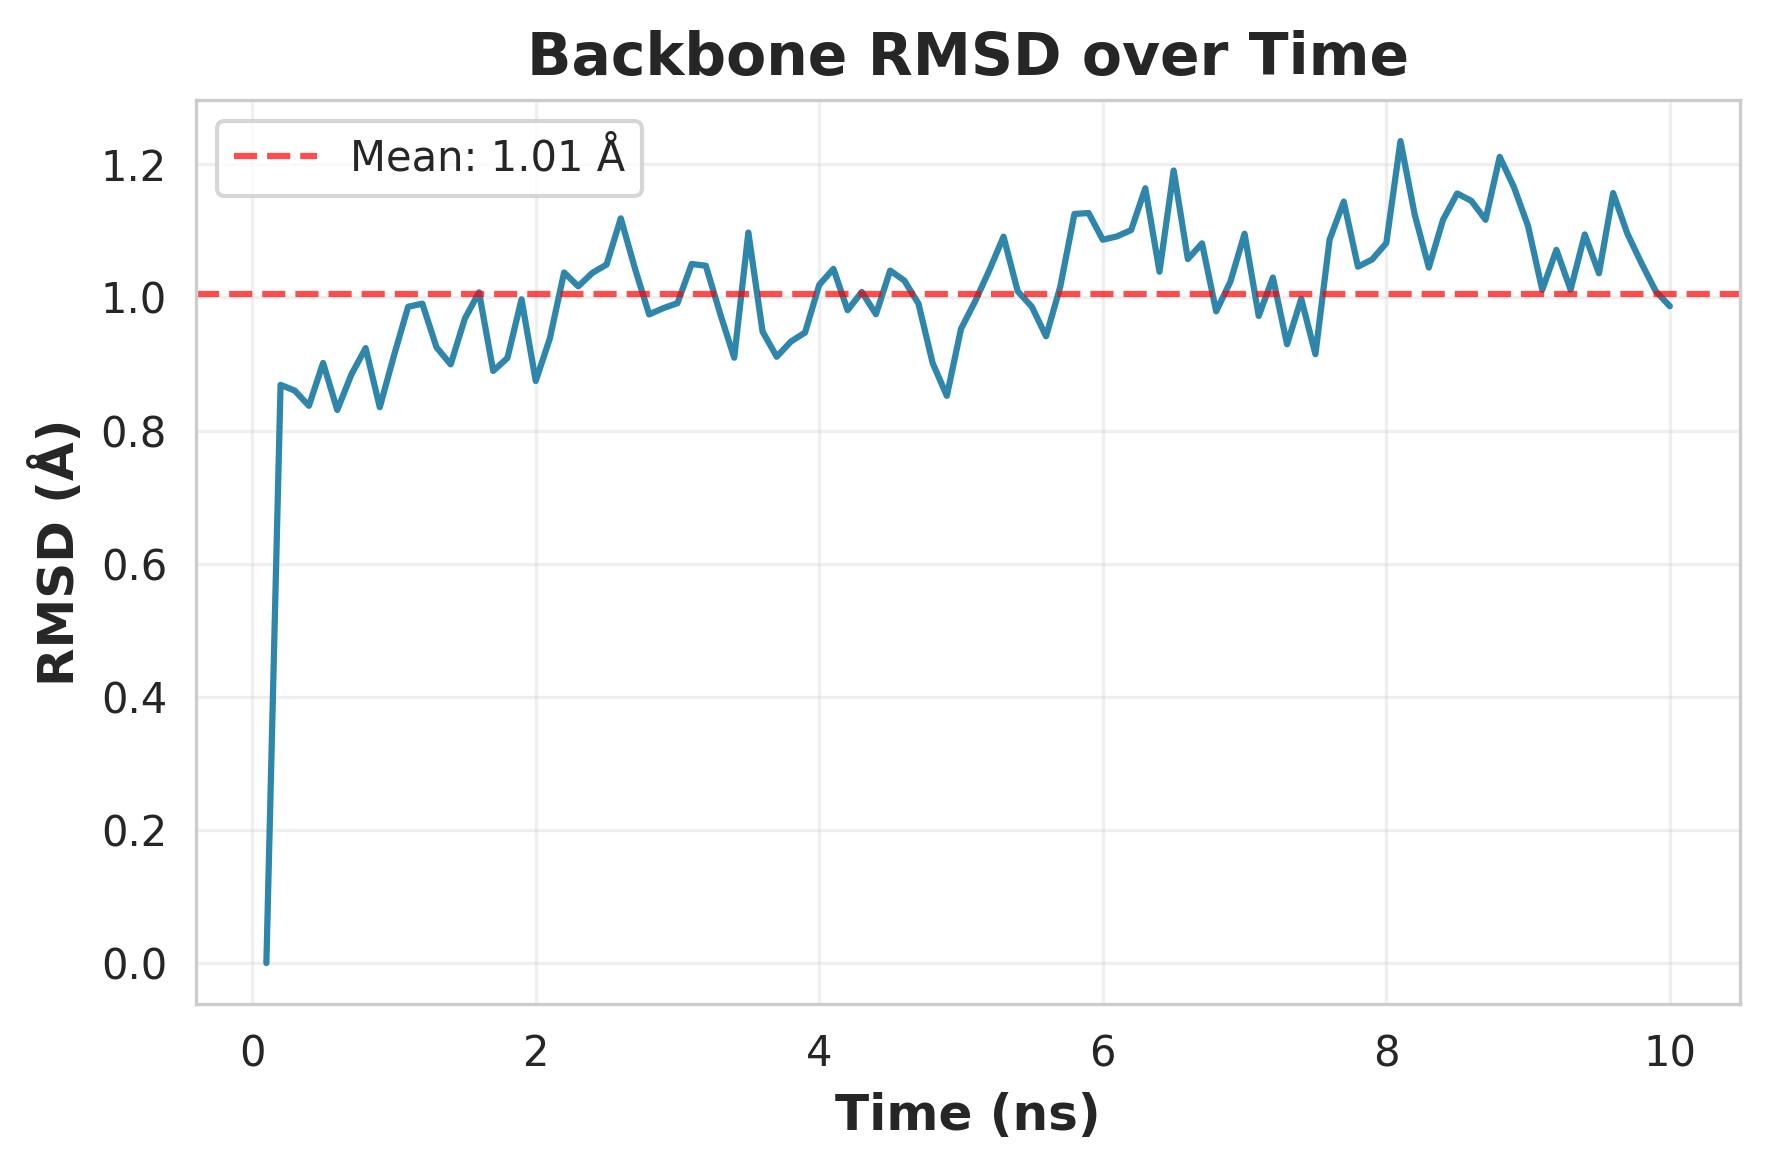

Calculating RMSF...
✓ RMSF plot saved to analysis_rmsf.png


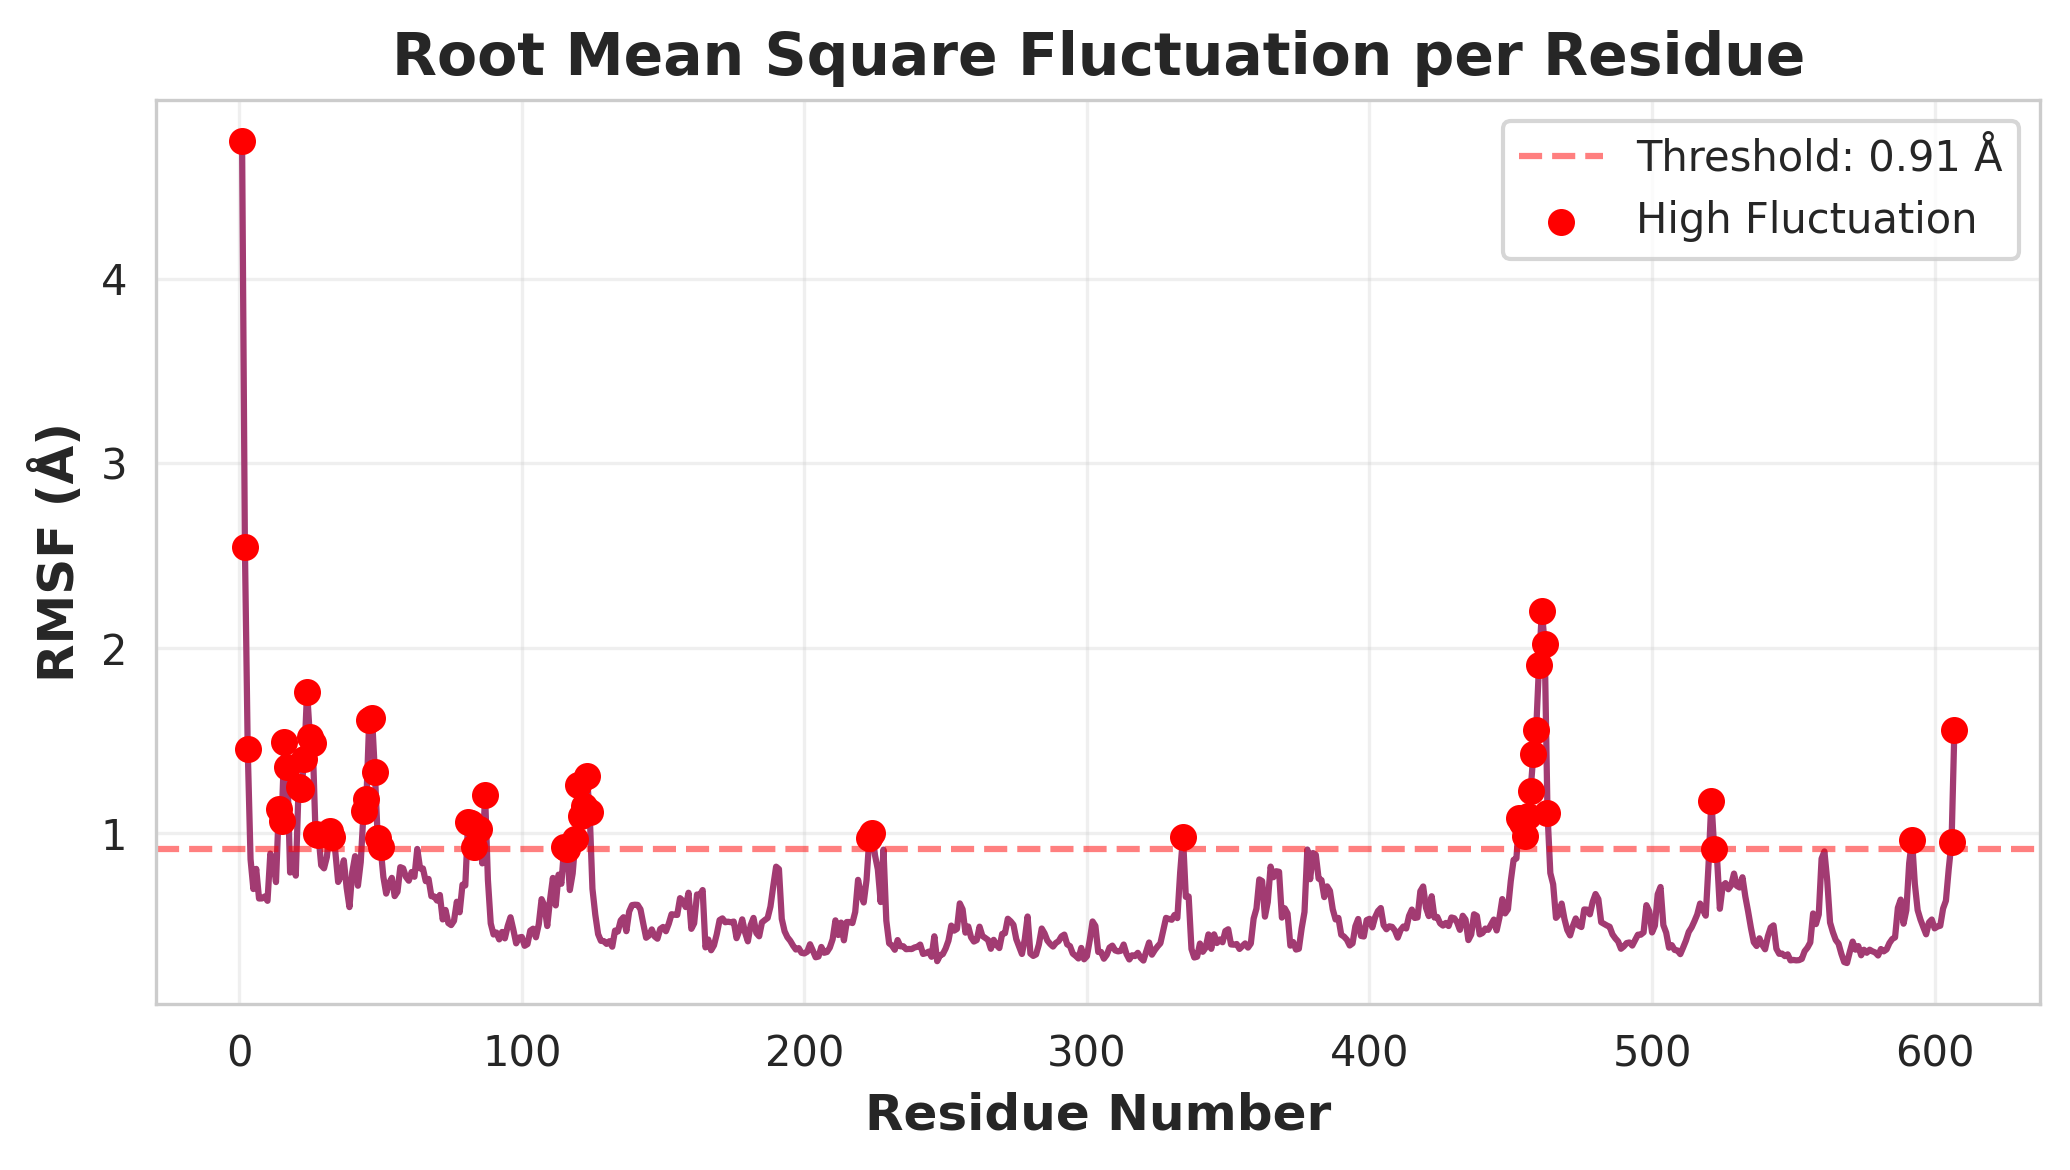

Calculating Radius of Gyration...
✓ Rg plot saved to analysis_rg.png


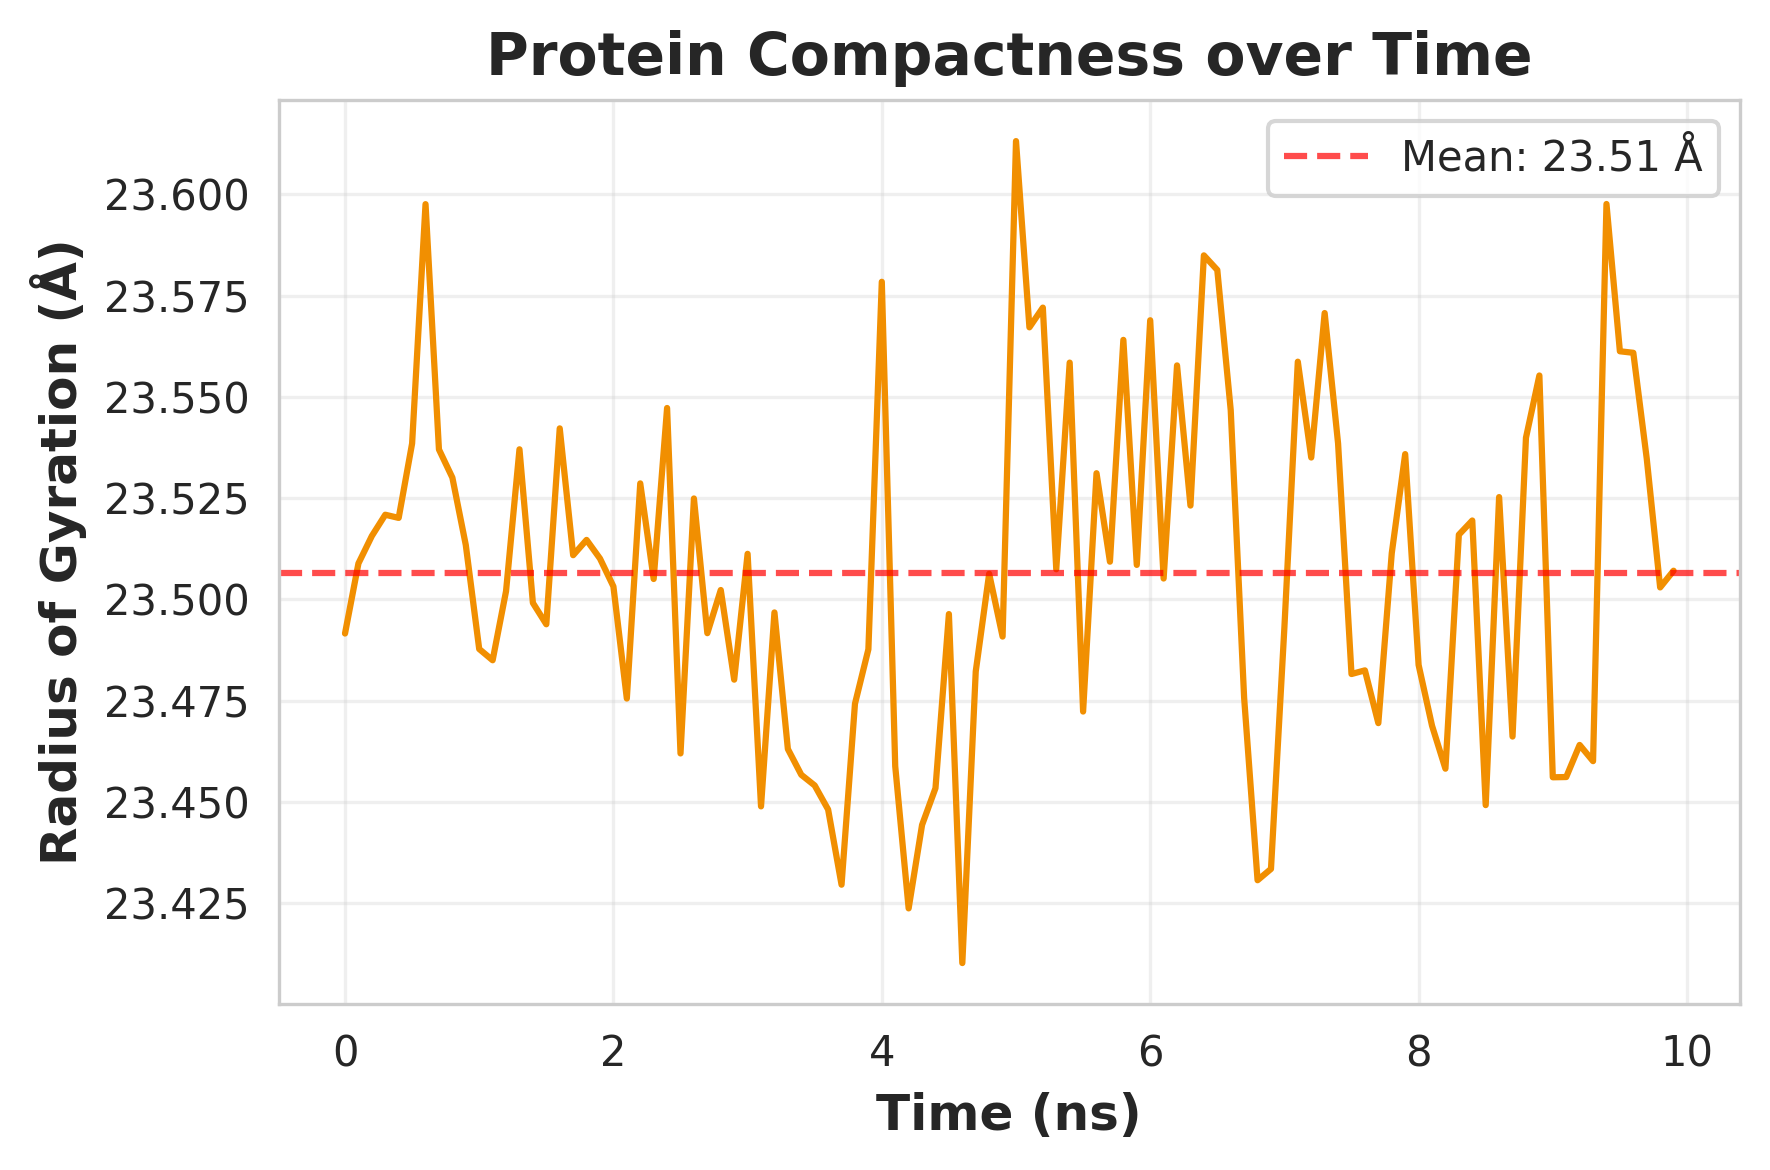

Calculating RMSD...
Calculating Radius of Gyration...
Calculating Free Energy Landscape...
✓ FEL plot saved to analysis_fel.png

GLOBAL MINIMUM INFORMATION
FEL Global Minimum Position:
  RMSD: 0.963 Å
  Rg:   23.499 Å

Closest Trajectory Frame:
  Frame Number: 14
  Time:         1.400 ns
  RMSD:         0.968 Å
  Rg:           23.499 Å

To extract this frame from your trajectory:
  Frame index (0-based): 14
  Time in trajectory:    1.400 ns



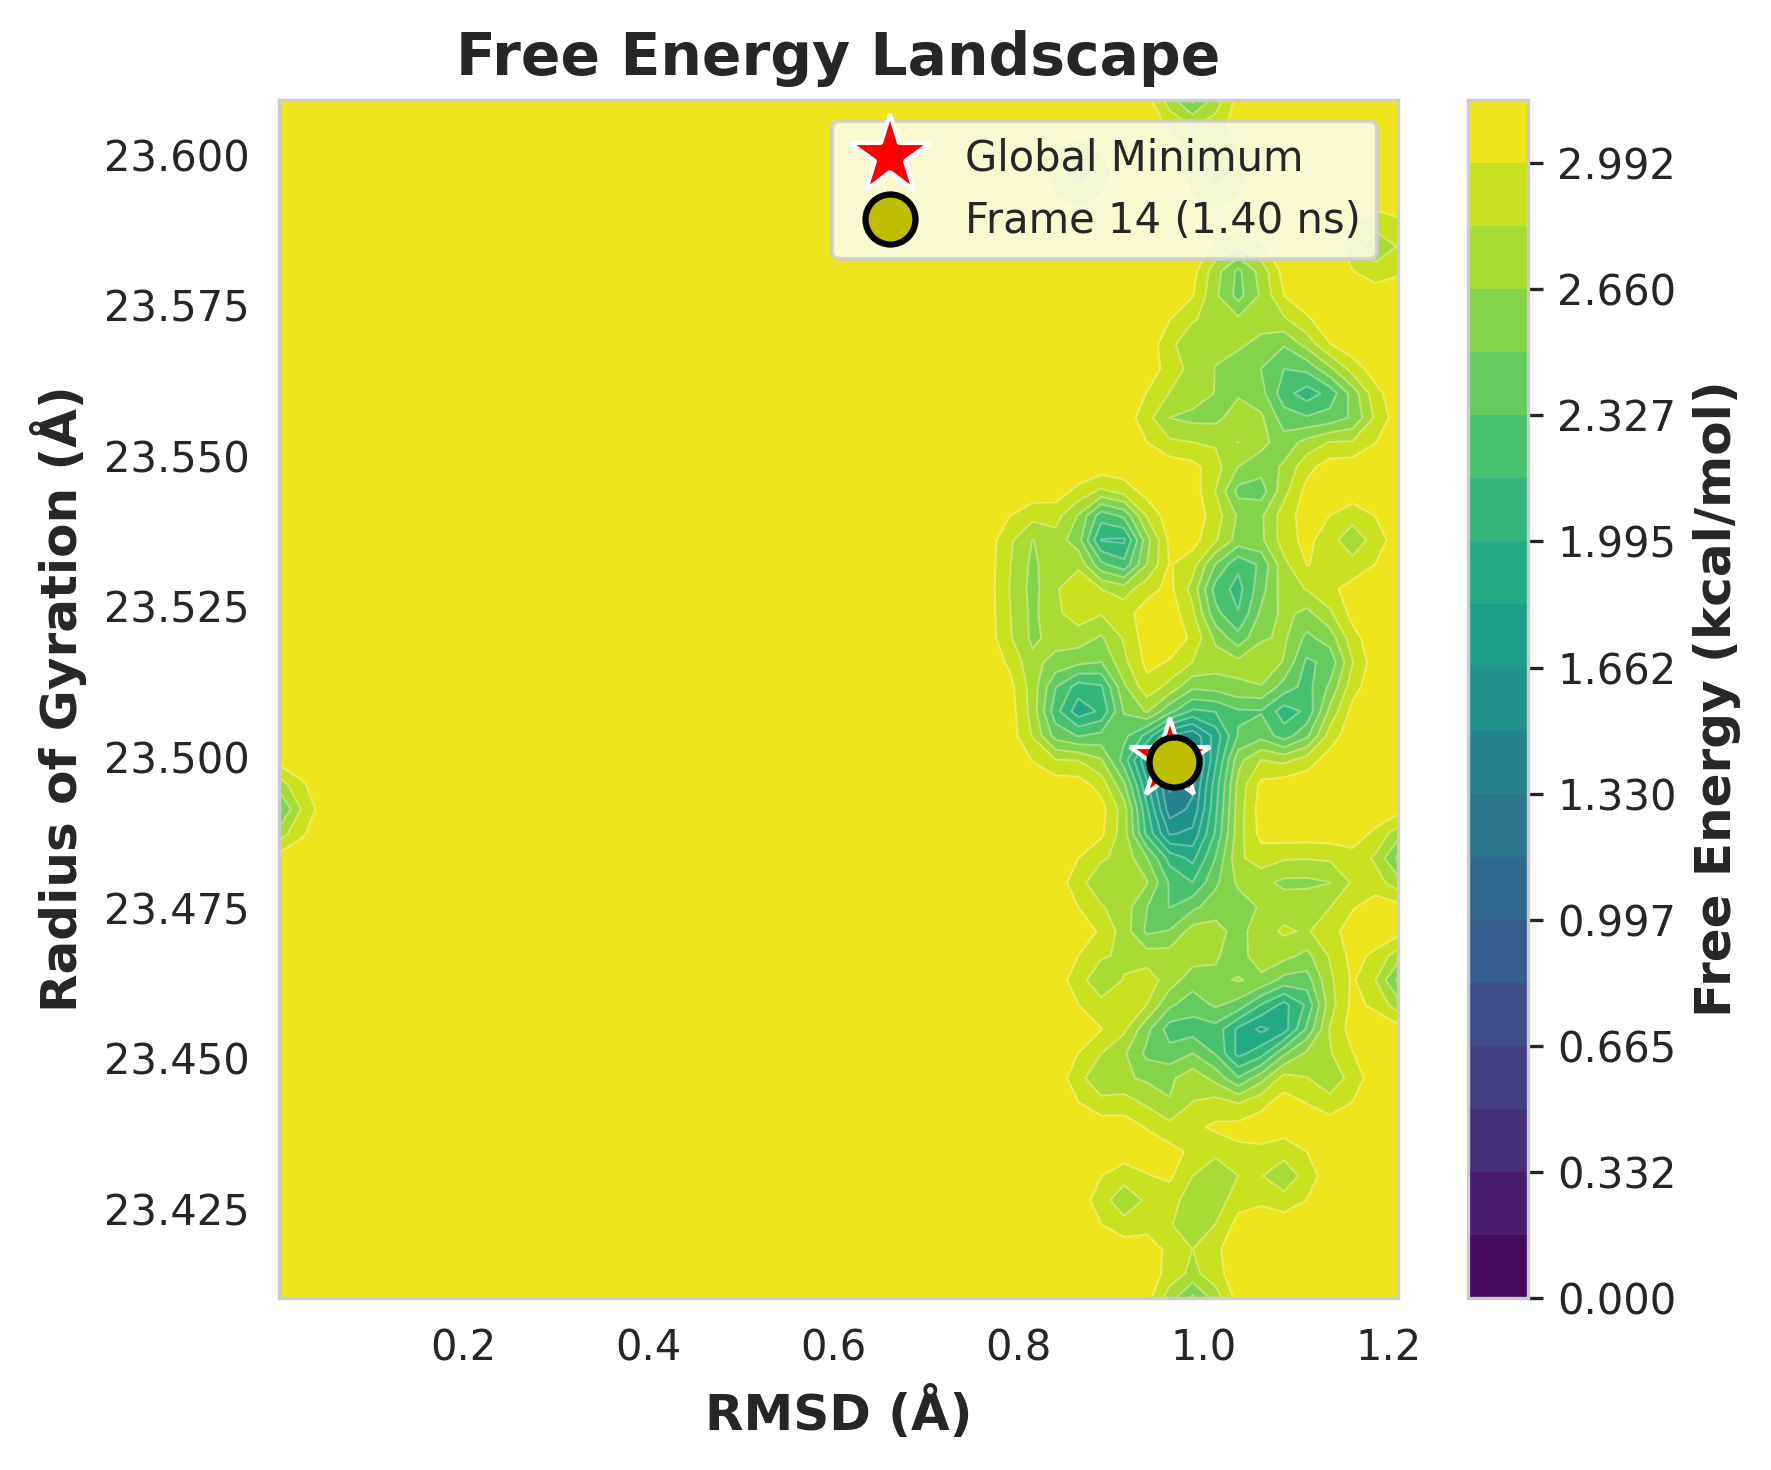

Calculating MM Binding Energy...
✓ Binding energy plot saved to analysis_binding_energy.png
  Mean Energy: 9195289.67 ± 47666.37 kJ/mol


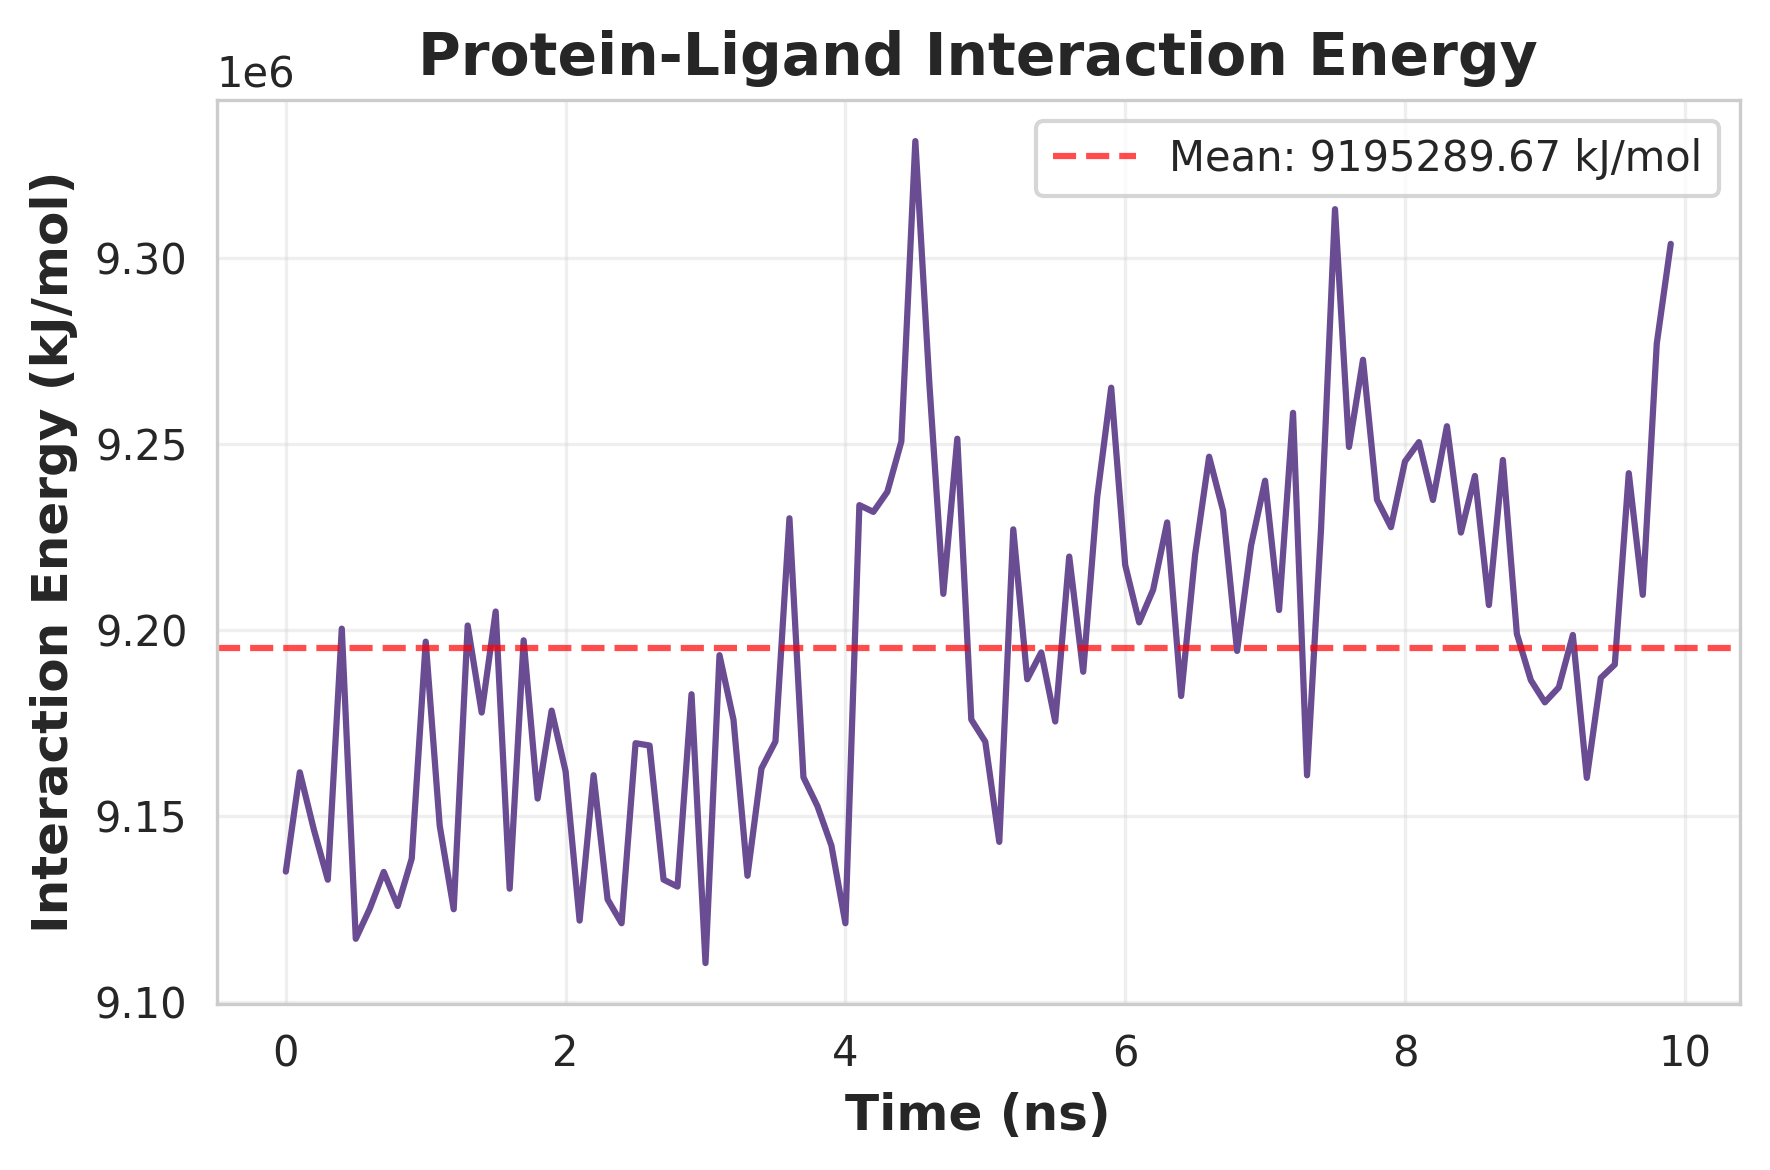

Calculating Protein-Ligand Distances...
✓ Distance plot saved to analysis_pl_distance.png


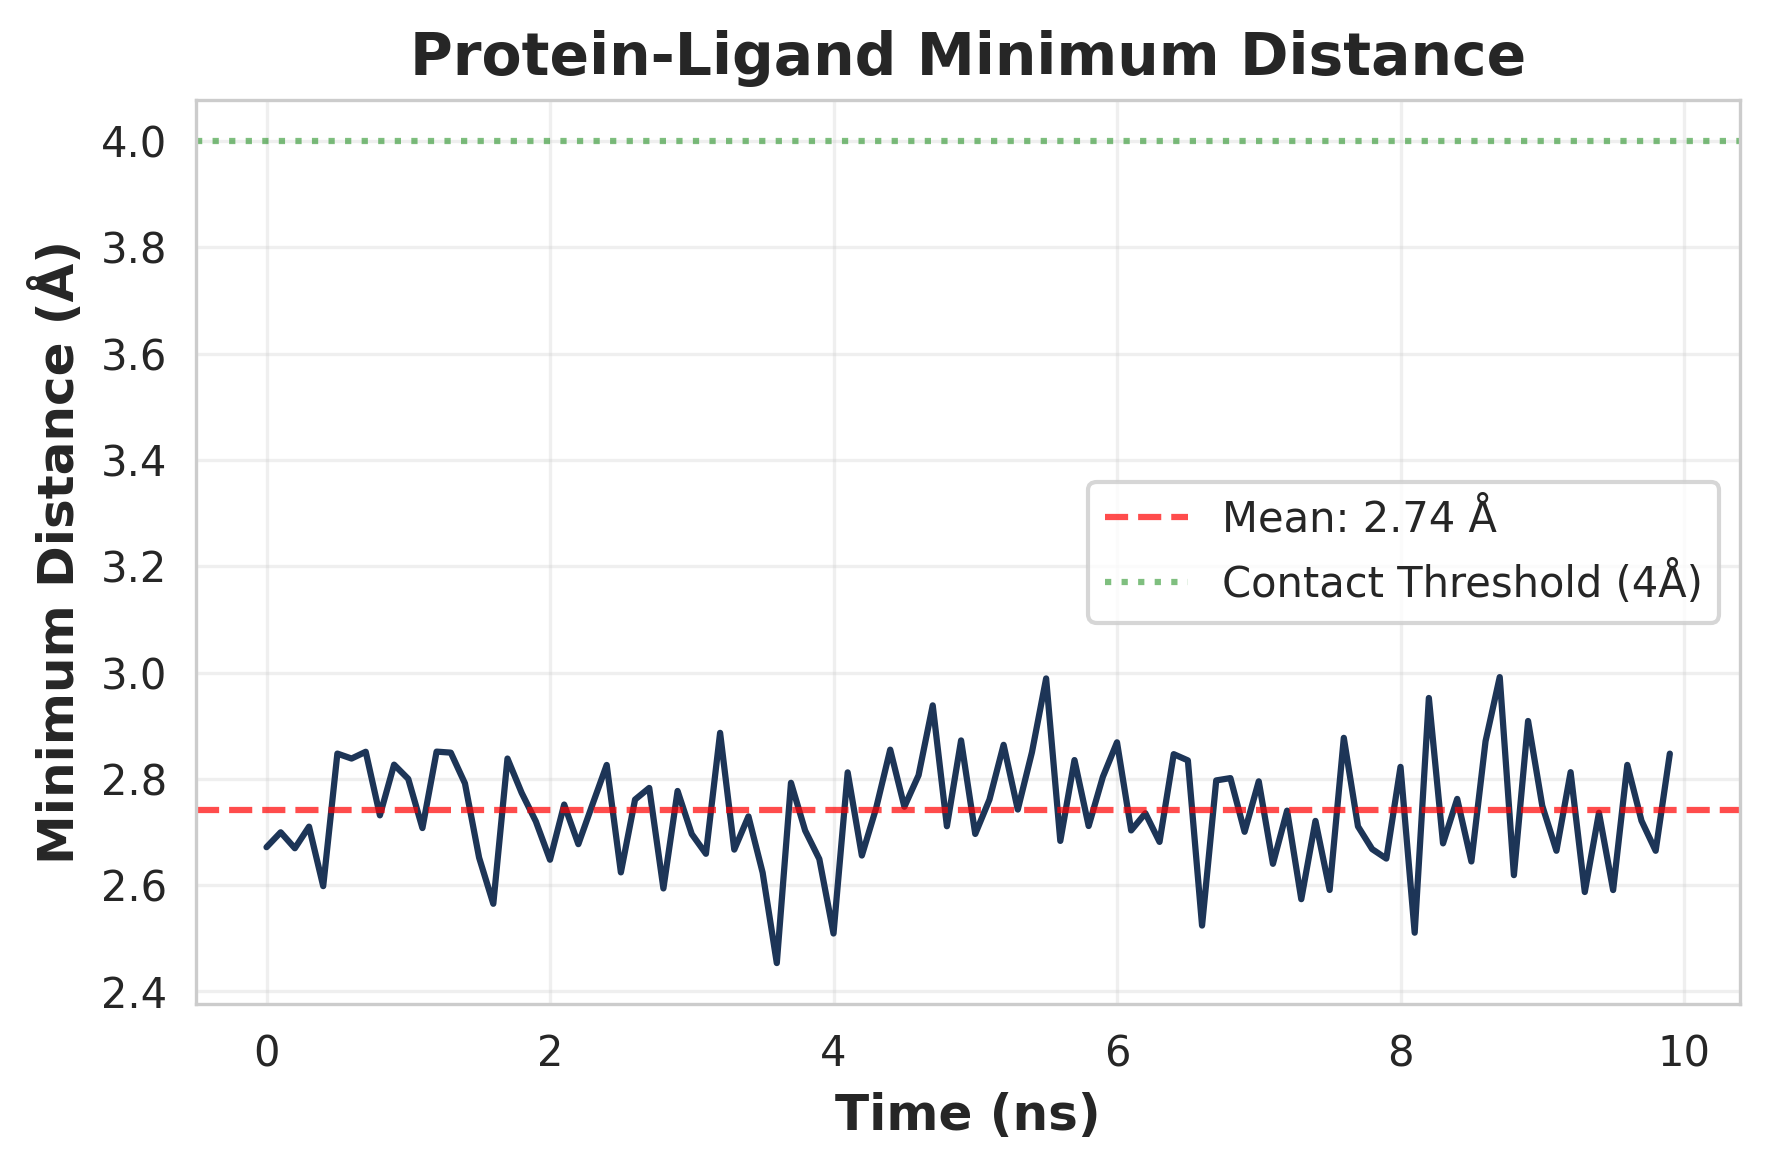


✓ Analysis Complete!


In [ ]:
#@title ##**Run Complete Analysis** { display-mode: "form" }

#@markdown ### File Inputs
topology_file = "prot_lig_equil.pdb"  #@param {type:"string"}
trajectory_file = "prot_lig_prod_1.dcd"  #@param {type:"string"}

#@markdown ### Selection Strings (MDAnalysis syntax)
protein_selection = "protein"  #@param {type:"string"}
ligand_selection = "resname LIG"  #@param {type:"string"}

#@markdown ### Output Prefix
output_prefix = "analysis"  #@param {type:"string"}

#@markdown ---
#@markdown **Instructions:**
#@markdown 1. Enter your topology file (PDB, GRO)
#@markdown 2. Enter your trajectory file (XTC, TRR, DCD)
#@markdown 3. Modify selection strings if needed
#@markdown 4. Click the play button ▶ to run!

# Run analysis
try:
    analyzer = MDAnalyzer(
        topology=topology_file,
        trajectory=trajectory_file,
        protein_selection=protein_selection,
        ligand_selection=ligand_selection
    )

    analyzer.run_complete_analysis(output_prefix=output_prefix)

except Exception as e:
    print(f"❌ Error: {e}")
    print("\nPlease check:")
    print("1. File paths are correct")
    print("2. Files exist in the current directory")
    print("3. Ligand selection string matches your topology")
    print("\nExample ligand selections:")
    print("  - resname LIG")
    print("  - resname ATP")
    print("  - resname UNK")
    print("  - resid 999")

Calculating RMSD...
Calculating Radius of Gyration...
Calculating Free Energy Landscape...
✓ FEL plot saved to custom_plot.png

GLOBAL MINIMUM INFORMATION
FEL Global Minimum Position:
  RMSD: 0.963 Å
  Rg:   23.499 Å

Closest Trajectory Frame:
  Frame Number: 14
  Time:         1.400 ns
  RMSD:         0.968 Å
  Rg:           23.499 Å

To extract this frame from your trajectory:
  Frame index (0-based): 14
  Time in trajectory:    1.400 ns



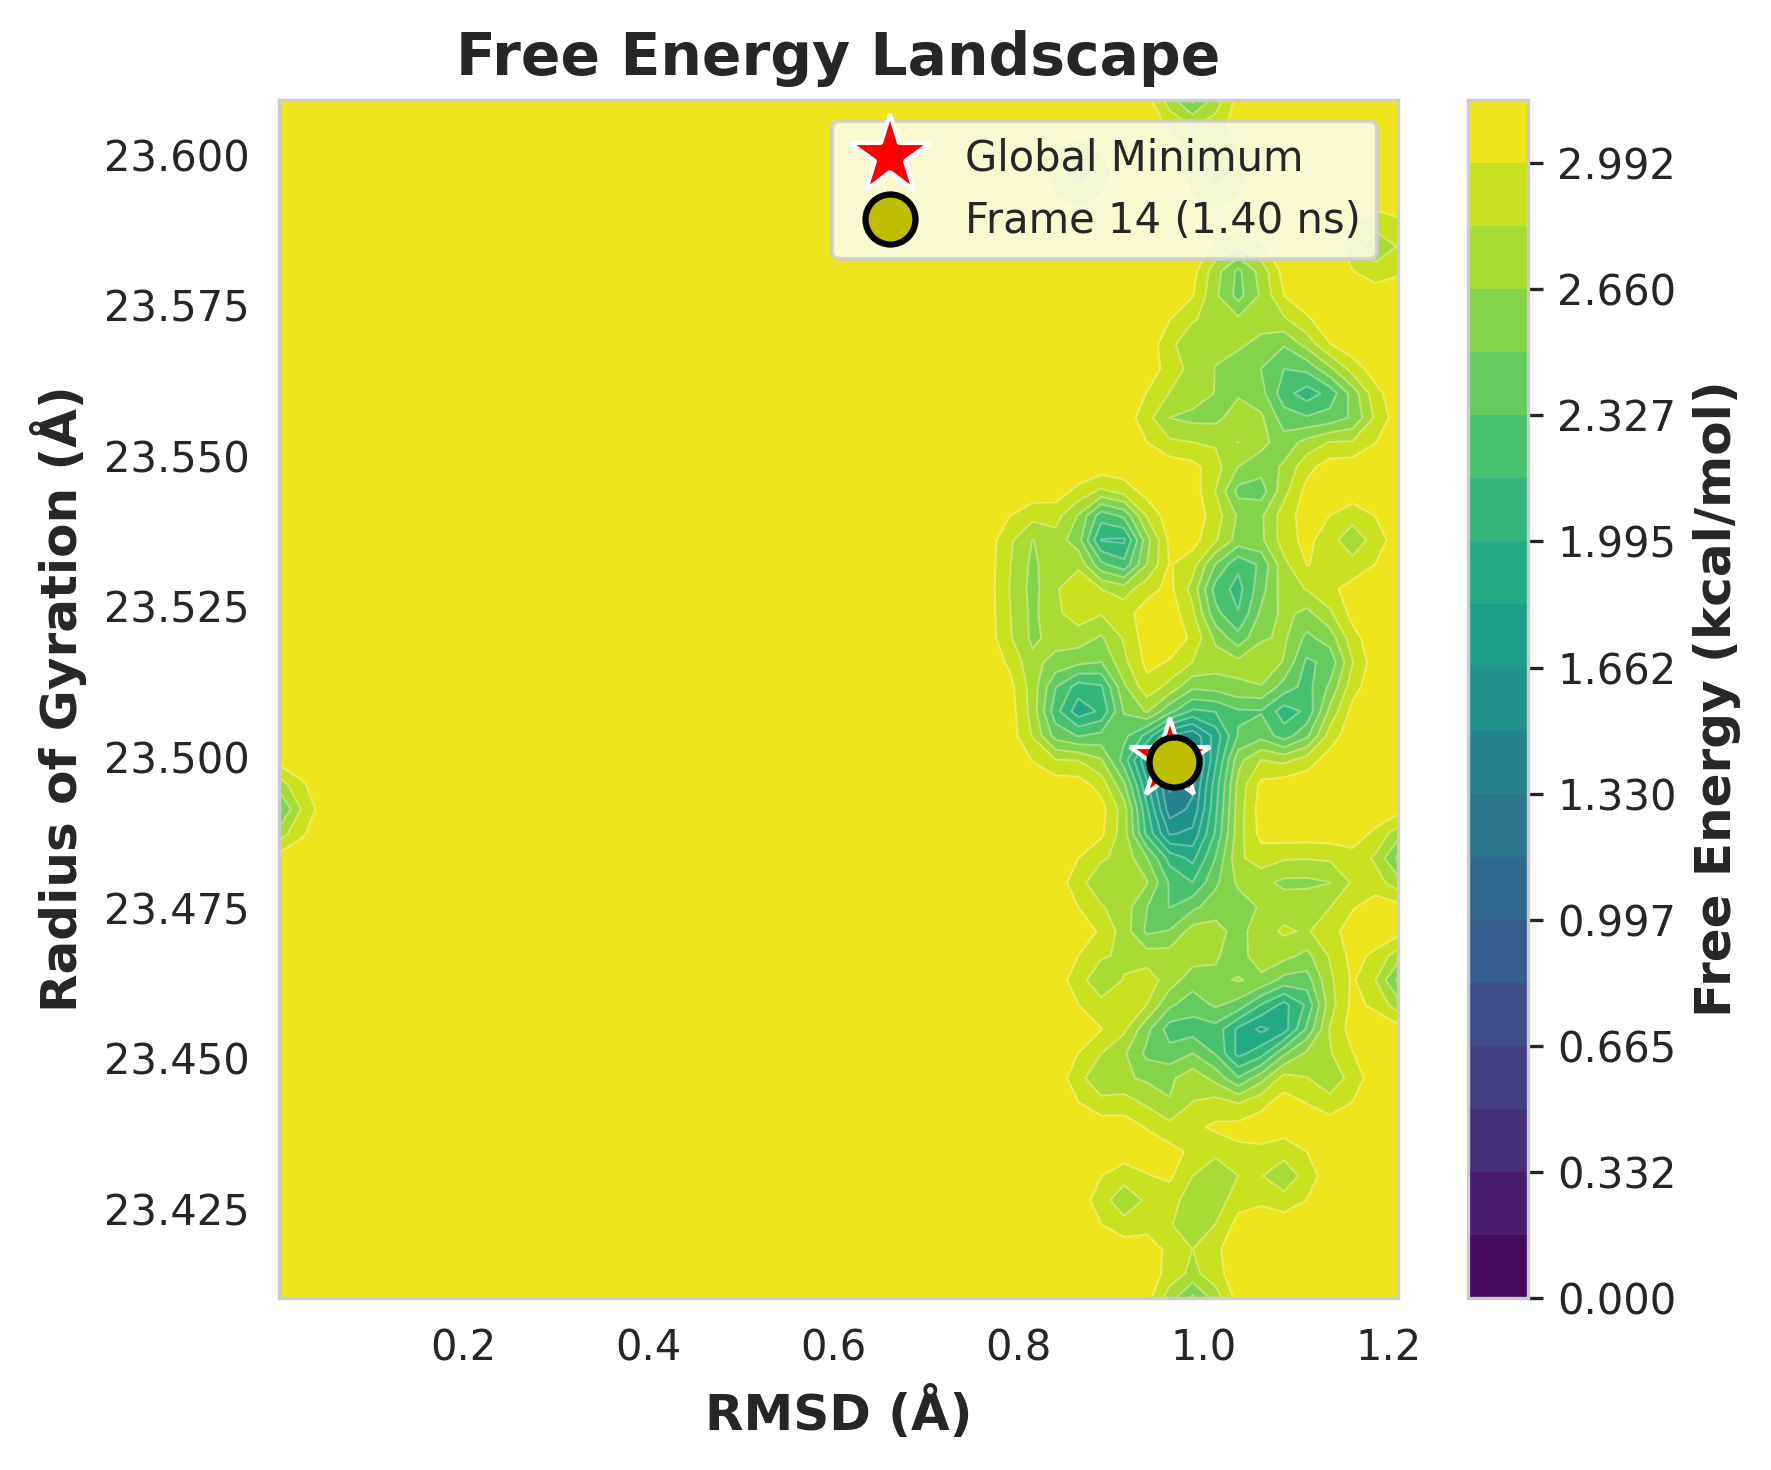

In [ ]:
#@title ##**Individual Analysis Options** { display-mode: "form" }

#@markdown If you want to run individual analyses instead of all at once:

analysis_type = "FEL"  #@param ["RMSD", "RMSF", "Rg", "FEL", "Binding Energy", "Distance"]
output_filename = "custom_plot.png"  #@param {type:"string"}

try:
    if analysis_type == "RMSD":
        analyzer.plot_rmsd(output_filename)
    elif analysis_type == "RMSF":
        analyzer.plot_rmsf(output_filename)
    elif analysis_type == "Rg":
        analyzer.plot_rg(output_filename)
    elif analysis_type == "FEL":
        analyzer.plot_free_energy_landscape(output_filename)
    elif analysis_type == "Binding Energy":
        analyzer.plot_binding_energy(output_filename)
    elif analysis_type == "Distance":
        analyzer.plot_protein_ligand_distance(output_filename)
except NameError:
    print("❌ Please run the main analysis cell first to create the analyzer object!")

In [ ]:
#@title ##**Extract Frame at Specific Time** { display-mode: "form" }

import MDAnalysis as mda
import numpy as np

#@markdown ### File Inputs
topology_file = "prot_lig_equil.pdb"  #@param {type:"string"}
trajectory_file = "prot_lig_prod_1.dcd"  #@param {type:"string"}

#@markdown ### Frame Selection
desired_time_ns = 1.4  #@param {type:"number"}

#@markdown ### What to Save
selection = "protein or resname LIG"  #@param ["all", "protein", "protein or resname LIG", "backbone", "protein or resname LIG or resname SOL"]

#@markdown ### Output
output_pdb = "extracted_frame_1_4_ns.pdb"  #@param {type:"string"}

#@markdown ---
#@markdown **Instructions:**
#@markdown 1. Enter your topology file (PDB, GRO)
#@markdown 2. Enter your trajectory file (XTC, TRR, DCD)
#@markdown 3. Enter the time in nanoseconds you want to extract
#@markdown 4. Choose what atoms to save
#@markdown 5. Name your output PDB file
#@markdown 6. Click the play button ▶ to run!

# ============================================================================
# EXTRACTION FUNCTION
# ============================================================================

def extract_frame_from_trajectory(topology_file, trajectory_file, time_ns,
                                   output_pdb="extracted_frame.pdb",
                                   selection="all"):
    """
    Extract a specific frame at a given time (ns) from MD trajectory
    """

    print("\n" + "="*60)
    print("EXTRACTING FRAME FROM TRAJECTORY")
    print("="*60)

    # Load trajectory
    print("\nLoading trajectory...")
    u = mda.Universe(topology_file, trajectory_file)
    print(f"✓ Loaded {len(u.trajectory)} frames")

    # Find all frame times
    times_ns = np.array([ts.time / 1000.0 for ts in u.trajectory])

    print(f"\nTrajectory info:")
    print(f"  First frame: {times_ns[0]:.3f} ns")
    print(f"  Last frame:  {times_ns[-1]:.3f} ns")
    print(f"  Total time:  {times_ns[-1] - times_ns[0]:.3f} ns")

    # Find closest frame to requested time
    frame_idx = np.argmin(np.abs(times_ns - time_ns))
    actual_time = times_ns[frame_idx]
    time_diff = abs(time_ns - actual_time)

    print(f"\nRequested time:  {time_ns:.3f} ns")
    print(f"Closest frame:   {frame_idx}")
    print(f"Actual time:     {actual_time:.3f} ns")
    print(f"Time difference: {time_diff:.3f} ns")

    # Go to that frame
    u.trajectory[frame_idx]

    # Select atoms to save
    atoms = u.select_atoms(selection)
    print(f"\nSelection: '{selection}'")
    print(f"Atoms to save: {len(atoms)}")

    # Save PDB
    atoms.write(output_pdb)

    print(f"\n✓ SUCCESS!")
    print(f"✓ Saved to: {output_pdb}")
    print("="*60 + "\n")

    return frame_idx, actual_time

# ============================================================================
# RUN EXTRACTION
# ============================================================================

frame_idx, actual_time = extract_frame_from_trajectory(
    topology_file=topology_file,
    trajectory_file=trajectory_file,
    time_ns=desired_time_ns,
    output_pdb=output_pdb,
    selection=selection
)

print(f"\n🎯 Frame {frame_idx} at {actual_time:.3f} ns saved to {output_pdb}")


EXTRACTING FRAME FROM TRAJECTORY

Loading trajectory...
✓ Loaded 100 frames

Trajectory info:
  First frame: 0.100 ns
  Last frame:  10.000 ns
  Total time:  9.900 ns

Requested time:  1.400 ns
Closest frame:   13
Actual time:     1.400 ns
Time difference: 0.000 ns

Selection: 'protein or resname LIG'
Atoms to save: 9344

✓ SUCCESS!
✓ Saved to: extracted_frame_1_4_ns.pdb


🎯 Frame 13 at 1.400 ns saved to extracted_frame_1_4_ns.pdb


## Tips & Troubleshooting

### Common Selection Strings

**Protein selections:**
- `protein` - All protein atoms
- `backbone` - Backbone atoms (N, CA, C, O)
- `name CA` - C-alpha atoms only
- `protein and resid 1-100` - Specific residue range

**Ligand selections:**
- `resname LIG` - Residue named LIG
- `resname ATP` - Residue named ATP
- `resid 999` - Residue number 999
- `not protein and not resname SOL` - Non-protein, non-solvent

### File Format Support

**Topology files:** PDB, GRO, PSF, TOP  
**Trajectory files:** XTC, TRR, DCD, NetCDF

### Performance Notes

- Large trajectories (>10,000 frames) may take several minutes
- The MM binding energy calculation is fast but approximate
- For more accurate energies, use MMPBSA or MMGBSA externally

### Citation

Notebook supported by MDAnalysis:

```
Michaud-Agrawal et al. (2011) MDAnalysis: A toolkit for the analysis of molecular dynamics simulations.
J. Comput. Chem. 32: 2319-2327. DOI: 10.1002/jcc.21787
```

---

**Developed by:** SciLearningWorkshops LLC  
**Version:** 1.0  
**Last Updated:** December 2025